# Loan Approval Prediction Project
This notebook preprocesses the dataset, visualizes patterns, trains ML models, and evaluates performance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
data = pd.read_csv('C:/Users/Saee Beri/OneDrive/Desktop/Msc Data Science/Sem 2/Loan_Approval Prediction dataset.csv')

In [4]:
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2.0,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0.0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3.0,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2.0,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1.0,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [5]:
print("Dataset Shape:", data.shape)
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (598, 13)

Missing Values:
Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
# Separate categorical and numerical columns
cat_cols = data.select_dtypes(include='object').columns.tolist()
num_cols = data.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Numerical Columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [7]:
# Handle missing values
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[num_cols] = num_imputer.fit_transform(data[num_cols])
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

print("Missing values handled successfully!")

Missing values handled successfully!


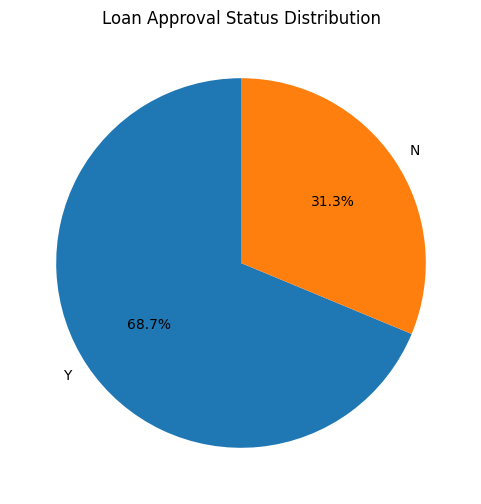

In [8]:
# Visualize Loan Status Distribution
plt.figure(figsize=(6,6))
data['Loan_Status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Loan Approval Status Distribution")
plt.ylabel("")
plt.show()

for above graph- approved loans("Y") ie 68.7%, not approved loans("N") ie 31.3%

In [9]:
# Encode categorical variables
label_encoder = LabelEncoder()

for col in cat_cols:
    data[col] = label_encoder.fit_transform(data[col])

print("Categorical variables encoded successfully!")
data.head()

Categorical variables encoded successfully!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0.0,0,0,5849.0,0.0,144.968804,360.0,1.0,2,1
1,1,1,1,1.0,0,0,4583.0,1508.0,128.000000,360.0,1.0,0,0
2,2,1,1,0.0,0,1,3000.0,0.0,66.000000,360.0,1.0,2,1
3,3,1,1,0.0,1,0,2583.0,2358.0,120.000000,360.0,1.0,2,1
4,4,1,0,0.0,0,0,6000.0,0.0,141.000000,360.0,1.0,2,1


In [10]:
# Normalize numerical features
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

print("Numerical features normalized successfully!")
data.head()

Numerical features normalized successfully!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0.000000,0,0,0.070489,0.000000,0.212120,0.74359,1.0,2,1
1,1,1,1,0.333333,0,0,0.054830,0.036192,0.185647,0.74359,1.0,0,0
2,2,1,1,0.000000,0,1,0.035250,0.000000,0.088924,0.74359,1.0,2,1
3,3,1,1,0.000000,1,0,0.030093,0.056592,0.173167,0.74359,1.0,2,1
4,4,1,0,0.000000,0,0,0.072356,0.000000,0.205928,0.74359,1.0,2,1


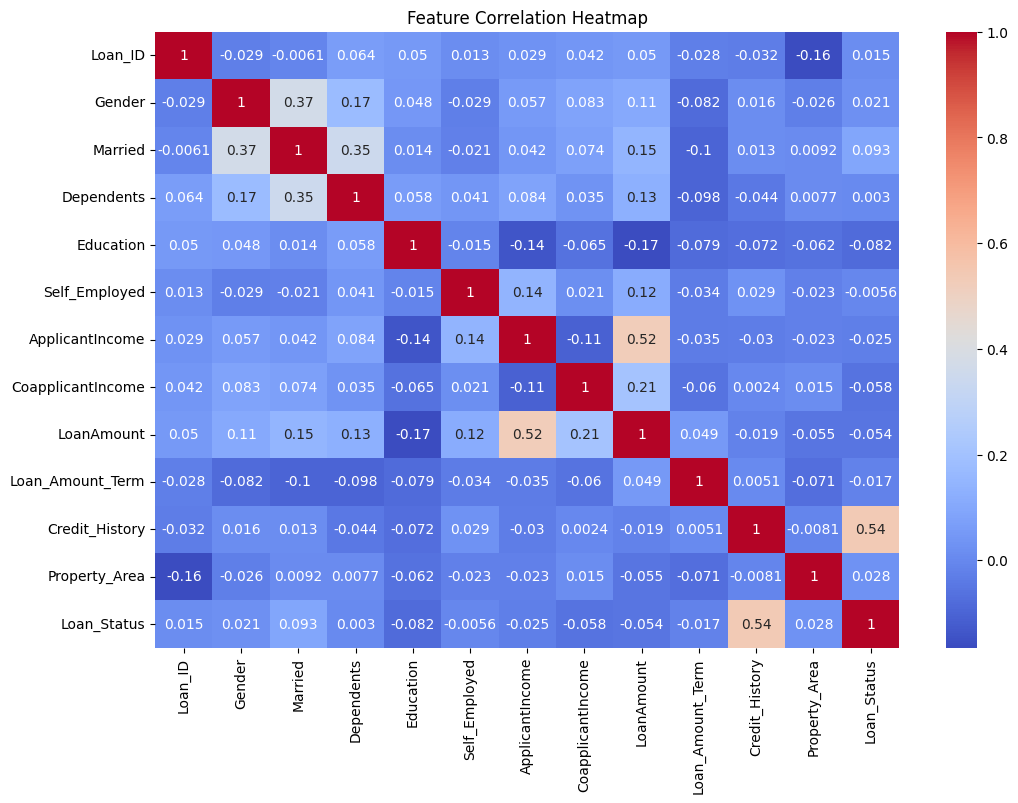

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
# Feature and target split
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (478, 12)
Testing Size: (120, 12)


C:\Users\Saee Beri\AppData\Local\Temp\ipykernel_13916\1181494946.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette=custom_palette)
C:\Users\Saee Beri\AppData\Local\Temp\ipykernel_13916\1181494946.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.countplot(x=data[col], palette=custom_palette)
C:\Users\Saee Beri\AppData\Local\Temp\ipykernel_13916\1181494946.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette=custom_palette)
C:\Users\Saee Beri\AppData\Local\Temp\ipykernel_13916\1181494946.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.

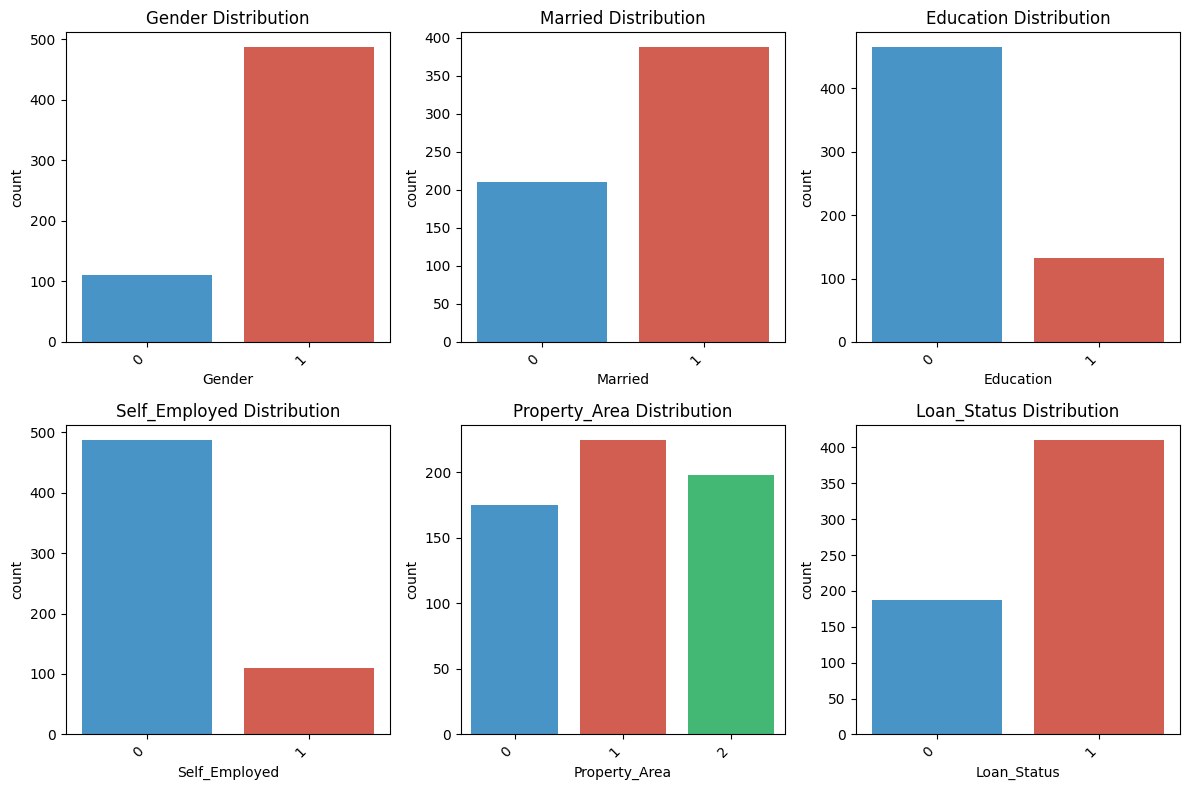

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = ["#3498db", "#e74c3c", "#2ecc71", "#f1c40f", "#9b59b6", "#1abc9c"]

categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

# Create subplots for better visualization
plt.figure(figsize=(12, 8))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)  
    sns.countplot(x=data[col], palette=custom_palette) 
    plt.xticks(rotation=45, ha='right')  
    plt.title(f"{col} Distribution")

plt.tight_layout() 
plt.show()

In [14]:
# Model Training and Evaluation
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy])

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, y_pred))


Logistic Regression
----------------------------------------
Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.93      0.40      0.56        35
           1       0.80      0.99      0.88        85

    accuracy                           0.82       120
   macro avg       0.87      0.69      0.72       120
weighted avg       0.84      0.82      0.79       120


Decision Tree
----------------------------------------
Accuracy: 0.68
              precision    recall  f1-score   support

           0       0.45      0.51      0.48        35
           1       0.79      0.74      0.76        85

    accuracy                           0.68       120
   macro avg       0.62      0.63      0.62       120
weighted avg       0.69      0.68      0.68       120


Random Forest
----------------------------------------
Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.82      0.40      0.54        35
           1      

c:\Users\Saee Beri\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Saee Beri\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Saee Beri\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

                 Model  Accuracy
0  Logistic Regression  0.816667
2        Random Forest  0.800000
3                  SVM  0.708333
1        Decision Tree  0.675000
4                  KNN  0.641667


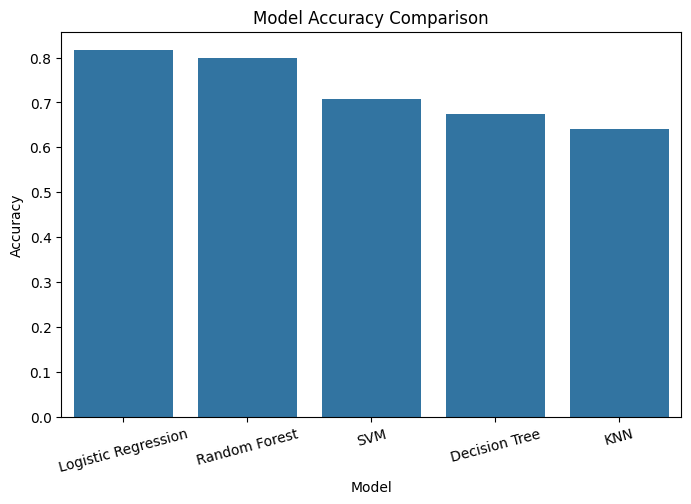

In [15]:
# Model Comparison
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.xticks(rotation=15)
plt.title("Model Accuracy Comparison")
plt.show()